--- PROXILINK ANALYTICS ENGINE ---
Detected Interaction Duration: 23.60 seconds
Max Signal Strength: -53.90 dBm
Final System Status: PROXILINK ACTIVE


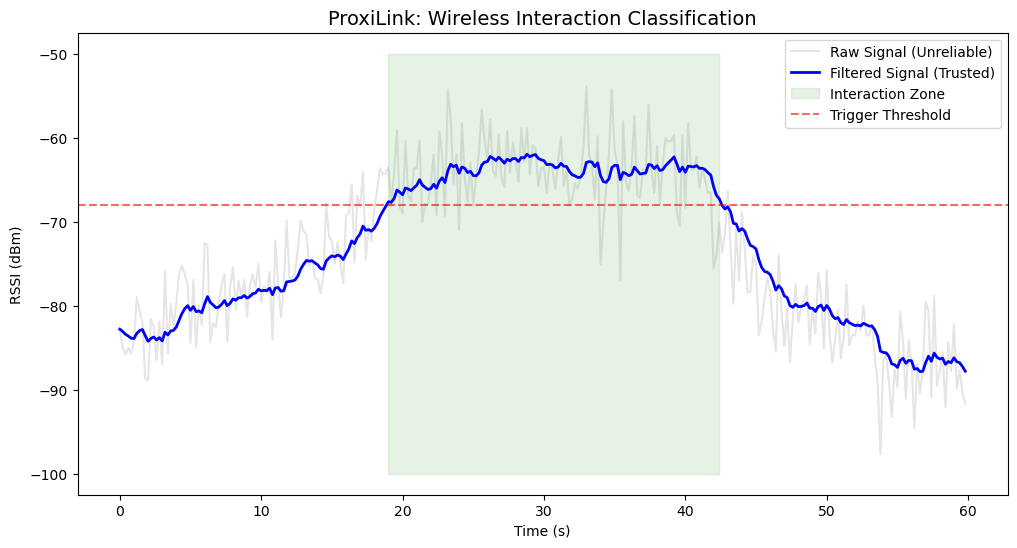

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# 1. SETUP: High-Frequency BLE Environment (5Hz)
t = np.arange(0, 60, 0.2) 
# Scenario: Worker approaches (6m to 0.8m), stays, then departs (to 10m)
true_dist = np.concatenate([
    np.linspace(6, 0.8, 100), 
    np.full(100, 0.8), 
    np.linspace(0.8, 10, 100)
])

# 2. PHYSICS: Signal Decay + Environmental Noise
np.random.seed(19)
# Shadowing Noise (4.0 dBm) simulates walls and human body interference
noise = np.random.normal(0, 4.0, len(t))
# Path Loss Formula: RSSI = A - 10 * n * log10(d)
rssi_raw = -65 - (10 * 2.4 * np.log10(true_dist)) + noise

df_proxi = pd.DataFrame({'Time': t, 'True_Dist': true_dist, 'RSSI_Raw': rssi_raw})

# 3. SIGNAL CONDITIONING: Sliding Window EWMA
# Removing the "flicker" so the social tracker is stable
df_proxi['RSSI_Clean'] = df_proxi['RSSI_Raw'].ewm(span=15, adjust=False).mean()

# 4. CLASSIFICATION: Interaction State Machine
# Threshold -68dBm is roughly 1.5 meters in this environment
df_proxi['State'] = np.where(df_proxi['RSSI_Clean'] > -68, "INTERACTING", "PROXIMITY")
df_proxi.loc[df_proxi['RSSI_Clean'] < -80, 'State'] = "FAR"

# 5. ANALYTICS REPORT
interaction_count = df_proxi[df_proxi['State'] == "INTERACTING"].shape[0]
total_sec = interaction_count * 0.2

print(f"--- PROXILINK ANALYTICS ENGINE ---")
print(f"Detected Interaction Duration: {total_sec:.2f} seconds")
print(f"Max Signal Strength: {df_proxi['RSSI_Raw'].max():.2f} dBm")
print(f"Final System Status: PROXILINK ACTIVE")

# 6. VISUAL PROOF
plt.figure(figsize=(12, 6))
plt.plot(df_proxi['Time'], df_proxi['RSSI_Raw'], alpha=0.2, color='gray', label='Raw Signal (Unreliable)')
plt.plot(df_proxi['Time'], df_proxi['RSSI_Clean'], color='blue', linewidth=2, label='Filtered Signal (Trusted)')
plt.fill_between(df_proxi['Time'], -100, -50, where=(df_proxi['State'] == "INTERACTING"), color='green', alpha=0.1, label='Interaction Zone')
plt.axhline(y=-68, color='red', linestyle='--', alpha=0.6, label='Trigger Threshold')
plt.title("ProxiLink: Wireless Interaction Classification", fontsize=14)
plt.ylabel("RSSI (dBm)")
plt.xlabel("Time (s)")
plt.legend()
plt.show()